This example uses a fully sampled 12-channel dataset from Calgary Campinas [3] processed to be oriented as outlined in Expected Input and our default parameters in config.json. First, we are importing the required modules for the MRI Defacer tool after installation.

In [13]:
import json
import os

import numpy as np 
from scipy.linalg import orth
from scipy.linalg import norm

from skimage.morphology import convex_hull_image 

from ROVir import rovir
from ROVir import top_nv
from ROVir import form_virtual_coil_data

from visualization import display_defaced
from visualization import compare_retention
from visualization import show_virtual_coils

from to_nifti import niftify
from automask import gen_mask

RED = '\033[91m'
GREEN = '\033[92m'
RESET = '\033[0m'

Defining helper functions in main.py used throughout the pipline.

In [14]:
def rsos(image):
    '''
    Computes the root sum of squares of the image across the channel dimension.
    
    Parameters
    ----------
        image -> np.ndarray: a 4D array of MRI image data, shape (x, y, z, ch)

    Returns
    ----------
        np.ndarray: a 3D array of the root sum of squares of the data, shape (x, y, z)
    '''
    
    return np.sqrt(np.sum(np.abs(image)**2, axis=3))


def set_masks(ROI, interference, gap=10):

    '''
    Manipulates the segmentation outputs to simplify shape. 
    
    Parameters
    ----------
        ROI -> np.ndarray: a 3D binary mask representing brain region, shape (x, y, z)
        interference -> np.ndarray: a 3D binary mask representing face region, shape (x, y, z)
        gap -> int: how wide of a gap between ROI and interference is wanted

    Returns
    ----------
        maskA -> np.ndarray: a 3D array of the brain region simplified
        maskB -> np.ndarray: a 3D array of the face region simplified 

    '''

    # simplify shape using convex hull
    maskA = convex_hull_image(ROI).astype(int)
    maskB = convex_hull_image(interference).astype(int)

    # get rid of overlap between masks by shrinking face mask
    overlap = maskA.astype(bool) & maskB.astype(bool) 
    while np.count_nonzero(overlap) != 0:
        _, y_face_true, z_face_true = np.nonzero(maskB) # find indices where face mask is nonzero
        zmax_face = np.max(z_face_true) # find top of face mask (closest to brain)
        ymin_face = np.min(y_face_true) # find edge of face mask (closest to neck)
        maskB[:, ymin_face, :] = 0 
        maskB[:, :, zmax_face] = 0
        overlap = maskA.astype(bool) & maskB.astype(bool) 

    # create addition gap by shrinking face mask
    for _ in range(gap):
        _, y_face_true, z_face_true = np.nonzero(maskB)
        zmax_face = np.max(z_face_true)
        ymin_face = np.min(y_face_true)
        maskB[:, ymin_face, :] = 0
        maskB[:, :, zmax_face] = 0

    return(maskA, maskB)


def make_A_B(image, nc, maskA, maskB):
    '''

    To compute the covariance matrices A and B that correspond to the brain and face regions, respectively.

    Parameters
    ----------
        image -> np.ndarray: the reconstructed image with shape (x, y, z, ch)
        nc -> int: the number of original coils 
        maskA -> np.ndarray: a 3D array of the brain region
        maskB -> np.ndarray: a 3D array of the face region

    Returns
    ----------
        A -> np.ndarray: the 2D covariance matrix corresponding to the brain, shape (nc, nc)
        B -> np.ndarray: the 2D covariance matrix corresponding to the face, shape (nc, nc)

    '''
    # to ensure 3D masks now has same dimensions as 4D image data
    maskA = np.expand_dims(maskA, axis = 3) 
    maskB = np.expand_dims(maskB, axis = 3)

    # applying masks to image data by entry-wise multiplication
    maskedA = image*maskA 
    maskedB = image*maskB 

    # compute the nc x nc covariance matrices
    A = np.reshape(maskedA, (-1, nc)).conj().T @ np.reshape(maskedA, (-1, nc))
    B = np.reshape(maskedB, (-1, nc)).conj().T @ np.reshape(maskedB, (-1, nc))

    # print(np.linalg.matrix_rank(B)) # checking rank of B

    return (A, B)

Now, we are loading the data and variables, such as the data shape and slice numbers.

In [15]:
if __name__ == "__main__": 

    # creating folders for nifti input, segmentations, and results
    os.makedirs('input', exist_ok = True)
    os.makedirs('segmentations', exist_ok = True)
    os.makedirs('results', exist_ok = True)

    # loading inputs from config file
    with open('config.json', 'r') as config_file:
        inputs = json.load(config_file)

    # loading the numpy raw k-space data and data ID
    data = np.load(inputs["data_path"]) 
    dataID = inputs["data_id"]

    print(GREEN + "Data has been successfully loaded" + RESET)

    # flipping data based on affine
    a11 = float(inputs["a11"])
    a22 = float(inputs["a22"])
    a33 = float(inputs["a33"])

    if a11 < 0: 
        data = data[::-1, :, :, :]

    if a22 < 0:
        data = data[:, ::-1, :, :]

    if a33 < 0:
        data = data[:, :, ::-1, :]

    # moving data axes to (x, y, z, ch) shape
    x_y_z_ch = inputs["x_y_z_channel"]
    sorted_ind = np.argsort(x_y_z_ch)
    data = np.moveaxis(data, [0, 1, 2, 3], sorted_ind) 

    # defining image slices to visualize  
    try:
        x_slice = int(inputs["x_slice"])
        y_slice = int(inputs["y_slice"])
        z_slice = int(inputs["z_slice"])
    except ValueError:
        print(RED + "One of your slices is not a valid integer. Change in config.json." + RESET)
        exit()

    if x_slice >= data.shape[0] or x_slice < -data.shape[0]:
        print(RED + f"Your x slice is out of bounds for image shape: {data.shape}"  + RESET )
        exit()

    if y_slice >= data.shape[1] or y_slice < -data.shape[1]:
        print(RED + f"Your y slice is out of bounds for image shape: {data.shape}"  + RESET)
        exit()

    if z_slice >= data.shape[2] or z_slice < -data.shape[2]:
        print(RED + f"Your z slice is out of bounds for image shape: {data.shape}"  + RESET)
        exit()

    try:
        gap = int(inputs["gap"])
    except ValueError:
        print(RED + "Your gap is not a valid integer. Change in config.json." + RESET)
        exit()


Data has been successfully loaded


Here, we make an initial reconstruction using the original k-space data to generate a NIfTI image. This reconstruction is later used to define the brain and face regions, but is later discarded.

In [16]:
    # fourier transform and shift data 
    og_image = np.fft.fftshift(np.fft.ifftn(np.fft.fftshift(data, axes = (0, 1, 2)), axes=(0, 1, 2)), axes = (0, 1, 2))
    og_image_rsos = rsos(og_image) # calculate rsos of image

Then, we generate the NIfTI image from the original image data. After, we call gen_mask, which is function that calls the TotalSegmentator API. TotalSegmentator will use the NIfTI image to output a binary mask of the face and brain regions.

In [17]:
    niftify(og_image_rsos, abs(a11), abs(a22), abs(a33), f'input/input_image_{dataID}') # save nifti of image
    gen_mask(f'input/input_image_{dataID}.nii', f'segmentations/output_mask_{dataID}.nii', dataID) # send nifti image for segmentation

[[   1.    0.    0.  -85.]
 [   0.    1.    0. -109.]
 [   0.    0.    1. -128.]
 [   0.    0.    0.    1.]]
Nifti file successfully saved
No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Resampling...
  Resampled in 1.56s
Predicting...


100%|██████████| 6/6 [00:28<00:00,  4.72s/it]


  Predicted in 50.64s
Resampling...
Saving segmentations...
  Saved in 12.30s
No GPU detected. Running on CPU. This can be very slow. The '--fast' or the `--roi_subset` option can help to reduce runtime.

If you use this tool please cite: https://pubs.rsna.org/doi/10.1148/ryai.230024

Generating rough segmentation for cropping...
  (Using more robust (but slower) 3mm model for cropping.)
Resampling...
  Resampled in 0.60s
Predicting...


100%|██████████| 1/1 [00:02<00:00,  2.19s/it]


  Predicted in 18.52s
Resampling...
  cropping from (170, 218, 256) to (167, 200, 176)
Resampling...
  Resampled in 1.06s
Predicting part 1 of 1 ...


100%|██████████| 4/4 [00:17<00:00,  4.28s/it]


  Predicted in 34.91s
Resampling...
Saving segmentations...
  Saved in 12.03s
Mask saved successfully


We then load the masks and simplify/manipulate it using the set_masks() function. The masking scheme we use has been tested to improve the ROVir framework's performance (in terms of brain region signal retention) compared to the raw brain and face masks.

In [18]:
    face_mask = np.load(f'segmentations/face_mask_{dataID}.npy') # load face mask
    brain_mask = np.load(f'segmentations/brain_mask_{dataID}.npy') # load brain mask
    print(GREEN + "Mask has been successfully loaded" + RESET)

    maskA, maskB = set_masks(brain_mask, face_mask, gap) # apply additional masking scheme
    print(GREEN + "Masks have been prepared" + RESET)


Mask has been successfully loaded
Masks have been prepared


With these masks, we can define covariance matrices using the make_A_B() function: brain_covar is the covariance matrix correlating with the brain region and face_covar is the covariance matrix correlating with the face region. These are used to find the eigenvectors, ranked in order of highest to lowest corresponding eigenvalues, of the generalized eigenvector problem (brain_covar)v = λ(face_covar)v. The eigenvalues correlate with the signal-to-interference ratio (in this case, the brain-to-face signal ratio), and thus the eigenvectors are the optimized linear combination weights to form virtual coils with signal concentrated in either the brain or face regions.

In [19]:
    nc = data.shape[-1] # get total number of original coils
    brain_covar, face_covar = make_A_B(og_image, nc, maskA, maskB) # create covariance matrices
    print(GREEN + "Brain and face covariance matrices have been computed" + RESET)

    eigenvec = rovir(nc, brain_covar, face_covar) # finding the eigenvectors for (brain_covar)v = λ(face_covar)v
    print(GREEN + "Eigenvectors computed" + RESET)

Brain and face covariance matrices have been computed
Eigenvectors computed


You can uncomment this line in main.py to view the defacing results as a function of the number of top virtual coils you retain. The formation of virtual coils is shown later in this notebook.

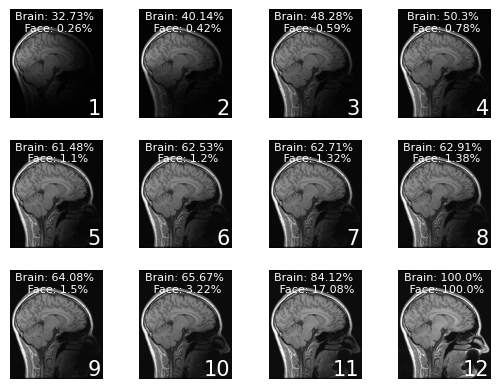

In [20]:
    %matplotlib inline
    compare_retention(data, eigenvec, brain_covar, face_covar, nc, x_slice) # visualize comparison between different # of coils retained

You can also uncomment this line in main.py to view the different virtual coils generated.

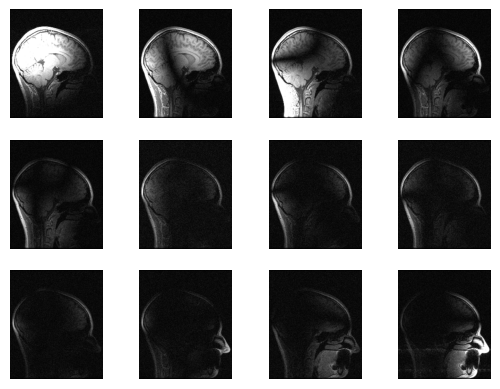

In [21]:
    show_virtual_coils(data, eigenvec, x_slice) # visualize all individual virtual coils

Here, we use the top_nv() function from the ROVir module to choose the number of top eigenvectors to retain. Retaining only the top coils which have high signal from the brain region only allows us to discard face region signal. See README.md or ROVir.py for more information on how this thresholding is done.

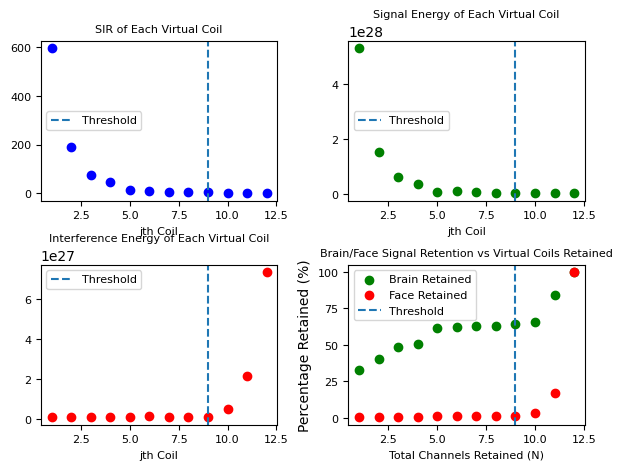

In [22]:
    method = inputs["threshold_method"] # load method/metric for selecting top coils
    threshold = inputs["threshold"] # load limit/requirement for selecting top coils
    
    # choose based on heuristics the number of eigenvectors to retain
    top_eigenvec = top_nv(eigenvec, nc, brain_covar, face_covar, method, threshold)


Here, we are generating the final defaced raw data, which is saved to the results folder as defaced_{dataID}.npy.

In [23]:
    print(f'The top nv eigenvectors contain the first {top_eigenvec} eigenvectors')
    eigenvec_retain = eigenvec[:,:top_eigenvec] # retain only the top eigenvectors 
    eigenvec_retain = orth(eigenvec_retain) # orthonormalize retained eigenvectors to noise-whiten

    orth_proj = eigenvec_retain @ eigenvec_retain.conj().T # find orthogonal projection matrix for span of retained eigenvectors
   
    # calculate signal retained from maskA region
    brain_retain = (norm((orth_proj @ brain_covar @ orth_proj), ord = 'fro') / norm (brain_covar, ord = 'fro'))*100
    print(GREEN + f'BRAIN SIGNAL RETAINED:{brain_retain}')

    # calculate signal retained from maskB region
    face_retain = (norm((orth_proj @ face_covar @ orth_proj), ord = 'fro') / norm (face_covar, ord = 'fro'))*100
    print(f'FACE SIGNAL RETAINED:{face_retain}' + RESET)
    
    # forming virtual coils, with eigenvectors as linear combo weights
    virtual_coil_data = form_virtual_coil_data(eigenvec_retain, data) 
    # print(virtual_coil_data.shape)
    print(GREEN + f'Virtual coils successfully formed' + RESET)

    # save final defaced raw data
    np.save(f'results/defaced_{dataID}.npy', virtual_coil_data)

The top nv eigenvectors contain the first 9 eigenvectors
BRAIN SIGNAL RETAINED:64.07670181075831
FACE SIGNAL RETAINED:1.4994143014537453
Virtual coils successfully formed


Here, we save a NIfTI image of the defaced data. This can be placed into volume rendering tools like 3DSlicer to visually inspect for any facial features left when evaluating the pipeline. In addition, the original image, defaced image, and masks are visualized.

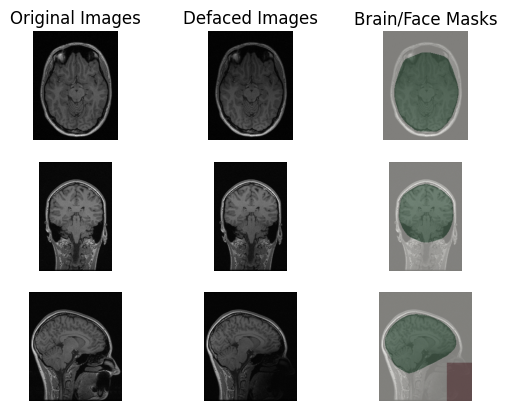

[[   1.    0.    0.  -85.]
 [   0.    1.    0. -109.]
 [   0.    0.    1. -128.]
 [   0.    0.    0.    1.]]
Nifti file successfully saved


In [24]:
    ####################################################################
    # FOLLOWING CODE IS FOR VISUALIZATION OF FINAL RESULT

    # compute image from virtual coil data
    defaced_image = np.fft.fftshift(np.fft.ifftn(np.fft.fftshift(virtual_coil_data, axes = (0, 1, 2)), axes=(0, 1, 2)), axes = (0, 1, 2))
    defaced_image = rsos(defaced_image) # find rsos of virtual coil image data

    display_defaced(og_image_rsos, defaced_image, x_slice, y_slice, z_slice, maskA, maskB, brain_retain, face_retain) # display images
    
    # save nifti of results for visualization in 3DSlicer
    niftify(defaced_image, abs(a11), abs(a22), abs(a33), f'results/defaced_{dataID}_n={top_eigenvec}_brain={brain_retain}_face={face_retain}')